In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


The value specified in an AutoRun registry key could not be parsed.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

# Get the directory Python is currently looking at
current_dir = Path.cwd()
print(f"Current working directory: {current_dir}")

Current working directory: D:\4 Learning\4-2026b Data Science\02-customer-segmentation-service\notebooks


In [3]:
path = "../data/online+retail/Online Retail.xlsx"

df = pd.read_excel(path)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
# Drop duplicates
df = df.drop_duplicates()
print(f"Total Rows: {df.shape[0]}")

Total Rows: 536641


In [7]:
# Delete null CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,401604.000000,401604,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,15281.160818
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,250.283037,NaN,69.764035,1714.006089


In [9]:
import re

val = set()
for x in df["InvoiceNo"]:
    val.update([" ".join(re.findall(r"[a-zA-Z]+", str(x)))])

print(val)

{'', 'C'}


In [10]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"Rows after removing cancelled Invoices: {df.shape[0]}")

Rows after removing cancelled Invoices: 392732


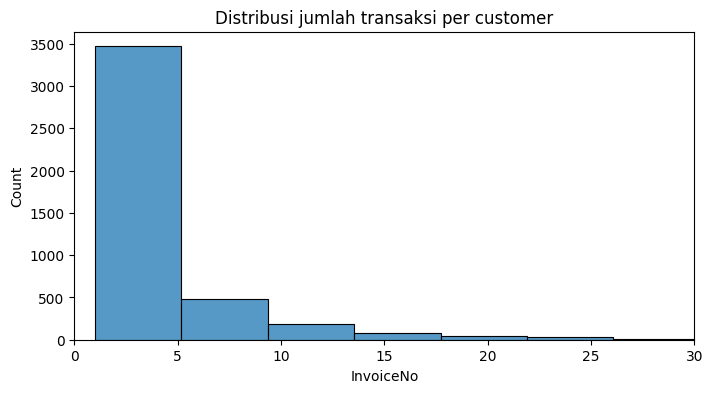

In [13]:
# jumlah transaksi (invoice unik) per customer
tx_per_customer = df.groupby("CustomerID")["InvoiceNo"].nunique()
tx_per_customer.describe()

plt.figure(figsize=(8,4))
sns.histplot(tx_per_customer, bins=50)
plt.xlim(0, tx_per_customer.quantile(0.99))
plt.title("Distribusi jumlah transaksi per customer")
plt.show()

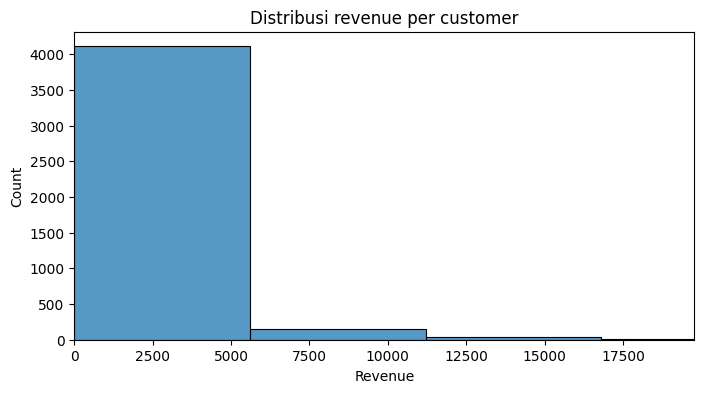

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [14]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

revenue_per_customer = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
revenue_per_customer.describe()

plt.figure(figsize=(8,4))
sns.histplot(revenue_per_customer, bins=50)
plt.xlim(0, revenue_per_customer.quantile(0.99))
plt.title("Distribusi revenue per customer")
plt.show()

# top 10 customer
revenue_per_customer.head(10)

2010-12-01 08:26:00 -> 2011-12-09 12:50:00


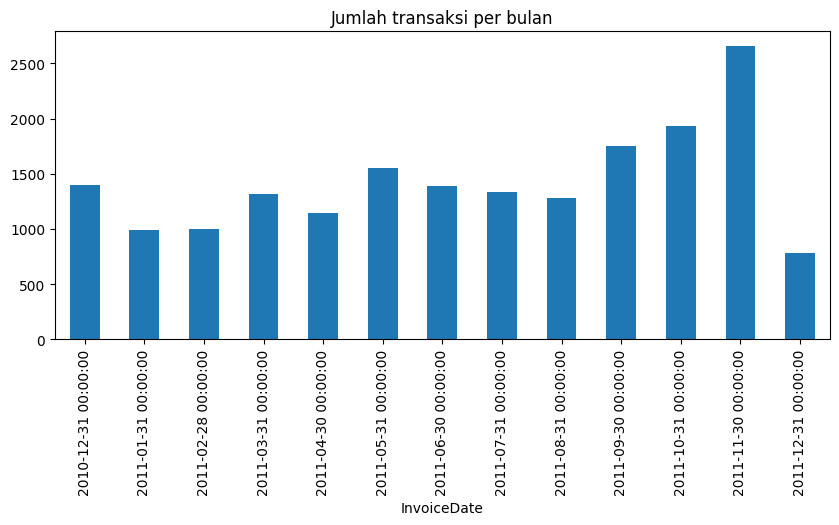

In [16]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())

# transaksi per bulan
df.set_index("InvoiceDate").resample("ME")["InvoiceNo"].nunique().plot(kind="bar", figsize=(10,4))
plt.title("Jumlah transaksi per bulan")
plt.show()

In [1]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
recency = df.groupby("CustomerID")["InvoiceDate"].max().apply(lambda x: (snapshot_date - x).days)

NameError: name 'df' is not defined